In [1]:
import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import sys
sys.path.append('..')

from src.models.cnn import ECG_CNN
from src.models.lstm import ECG_BiLSTM
from src.models.transformer import ECG_Transformer
from src.dataset import get_dataloaders
from src.utils.preprocessing import load_splits

# Load histories
with open('../results/metrics/cnn_history.json') as f:
    cnn_hist = json.load(f)
with open('../results/metrics/lstm_history.json') as f:
    lstm_hist = json.load(f)
with open('../results/metrics/transformer_history.json') as f:
    trans_hist = json.load(f)

# Summary
for name, hist in zip(['CNN', 'BiLSTM', 'Transformer'], [cnn_hist, lstm_hist, trans_hist]):
    best_f1 = max(hist['val_f1'])
    best_epoch = hist['val_f1'].index(best_f1) + 1
    total_epochs = len(hist['val_f1'])
    print(f"{name:12} | Best Val F1: {best_f1:.4f} | Best Epoch: {best_epoch:02d} | Total Epochs: {total_epochs}")

/opt/anaconda3/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


CNN          | Best Val F1: 0.9700 | Best Epoch: 10 | Total Epochs: 17
BiLSTM       | Best Val F1: 0.9599 | Best Epoch: 19 | Total Epochs: 26
Transformer  | Best Val F1: 0.9750 | Best Epoch: 26 | Total Epochs: 33


In [3]:
# Load test data
X_train, X_val, X_test, y_train, y_val, y_test = load_splits('../data/processed')
_, _, test_loader = get_dataloaders(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    batch_size=64
)

device = torch.device('cpu')
CLASS_NAMES = ['N', 'L', 'R', 'V', 'A']

def evaluate_model(model, checkpoint_path, loader, device):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X)
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

# Load config for model params
import yaml
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

# Evaluate all three
results = {}
for name, model in zip(
    ['CNN', 'BiLSTM', 'Transformer'],
    [
        ECG_CNN(num_classes=5, dropout=cfg['models']['cnn']['dropout']),
        ECG_BiLSTM(num_classes=5, hidden_size=cfg['models']['lstm']['hidden_size'], num_layers=cfg['models']['lstm']['num_layers'], dropout=cfg['models']['lstm']['dropout']),
        ECG_Transformer(num_classes=5, dropout=cfg['models']['transformer']['dropout'], max_len=180)
    ]
):
    ckpt = f'../results/{name.lower().replace("bilstm", "lstm")}_best.pt'
    labels, preds = evaluate_model(model, ckpt, test_loader, device)
    results[name] = {'labels': labels, 'preds': preds}
    print(f"{name} | Test Macro F1: {f1_score(labels, preds, average='macro'):.4f}")

CNN | Test Macro F1: 0.9691
BiLSTM | Test Macro F1: 0.9645
Transformer | Test Macro F1: 0.9713


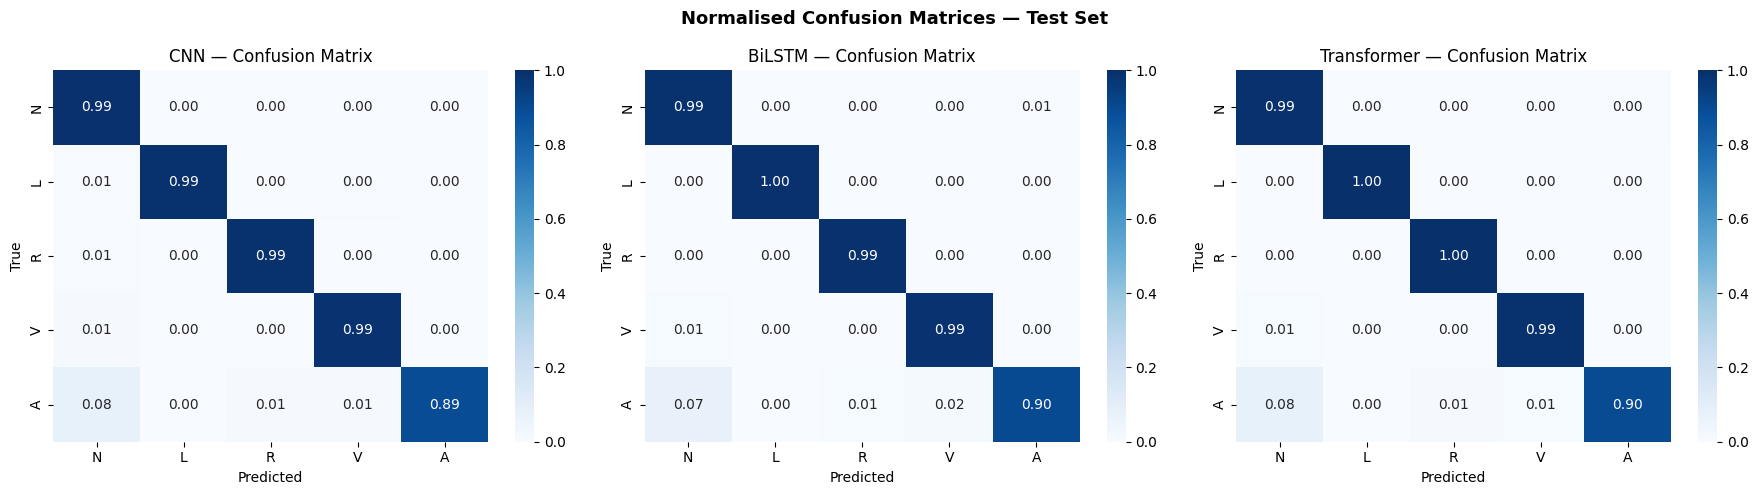

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
CLASS_NAMES = ['N', 'L', 'R', 'V', 'A']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Normalised Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrices.png', dpi=150)
plt.show()

In [5]:
import pandas as pd

rows = []
for name, res in results.items():
    report = classification_report(res['labels'], res['preds'],
                                   target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    row = {cls: round(report[cls]['f1-score'], 4) for cls in CLASS_NAMES}
    row['Macro F1'] = round(report['macro avg']['f1-score'], 4)
    row['Model'] = name
    rows.append(row)

df = pd.DataFrame(rows).set_index('Model')
df = df[CLASS_NAMES + ['Macro F1']]
print(df.to_string())

                  N       L       R       V       A  Macro F1
Model                                                        
CNN          0.9939  0.9934  0.9922  0.9736  0.8923    0.9691
BiLSTM       0.9930  0.9942  0.9931  0.9692  0.8731    0.9645
Transformer  0.9951  0.9979  0.9963  0.9862  0.8810    0.9713


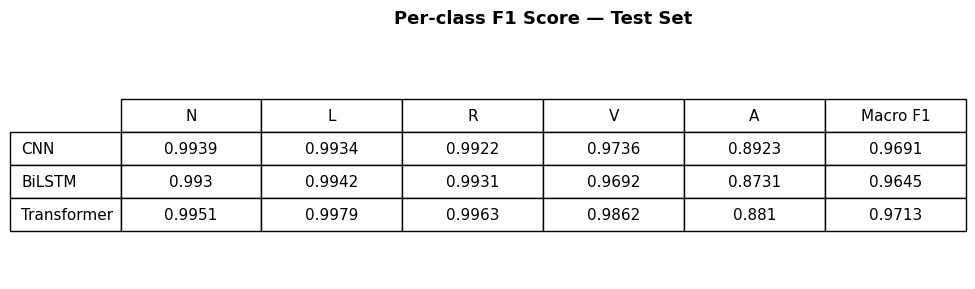

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(
    cellText=df.values.round(4),
    rowLabels=df.index,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
plt.title('Per-class F1 Score — Test Set', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../results/figures/metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()